# Imports

In [4]:
from lineagetree import read_from_mastodon
import numpy as np
import matplotlib.pyplot as plt
import h5py

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

import importlib # to reload functions for testing in notebooks

# Load Data

In [ ]:
# --- LOAD DIRECTORIES FOR DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 500 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

# Preparatory Steps

In [3]:
# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # for no downscaling (0-th level of the hdf5), (as measured in T7_3 data (dir = H:))
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

# PREPROCCESS IMAGE TO CREATE WATERSHED INPUT
im_for_ws = main.preprocess_im(raw_image)

full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]


# Adaptive Watershed

In [6]:
ws, all_seeds, missed_seeds, stat_table = main.ws_adaptive_mask(im_for_ws, seeds_array, min_int=np.percentile(im_for_ws.ravel(), 80), max_int=np.percentile(im_for_ws.ravel(), 99.9), 
                                                                percentage_list=[100, 99.99, 99.9, 99, 97, 95, 90, 80, 70])

Processing thresholds for watershed:: 100%|██████████| 9/9 [01:28<00:00,  9.86s/step]


In [8]:
utils.display_ws_thresholding_results(stat_table, all_seeds)

+------------+------------------+-------------+--------------+
| Percentage | Percentile Value | Found Seeds | Missed Seeds |
+------------+------------------+-------------+--------------+
|   100 %    |      166.0       |     44      |     758      |
+------------+------------------+-------------+--------------+
|  99.99 %   |      164.0       |      1      |     757      |
+------------+------------------+-------------+--------------+
|   99.9 %   |      155.0       |      8      |     749      |
+------------+------------------+-------------+--------------+
|    99 %    |      111.0       |     69      |     680      |
+------------+------------------+-------------+--------------+
|    97 %    |       83.0       |     108     |     572      |
+------------+------------------+-------------+--------------+
|    95 %    |       70.0       |     93      |     479      |
+------------+------------------+-------------+--------------+
|    90 %    |       52.0       |     152     |     327

# Segmentation Correction

In [6]:
# ws = main.add_lost_seeds(ws, seeds_array, missed_seeds)

# Visualization

In [9]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_image(seeds_array, colormap='#aaff00ff')
viewer.add_labels(ws)
napari.run()

What is the multiples problem:

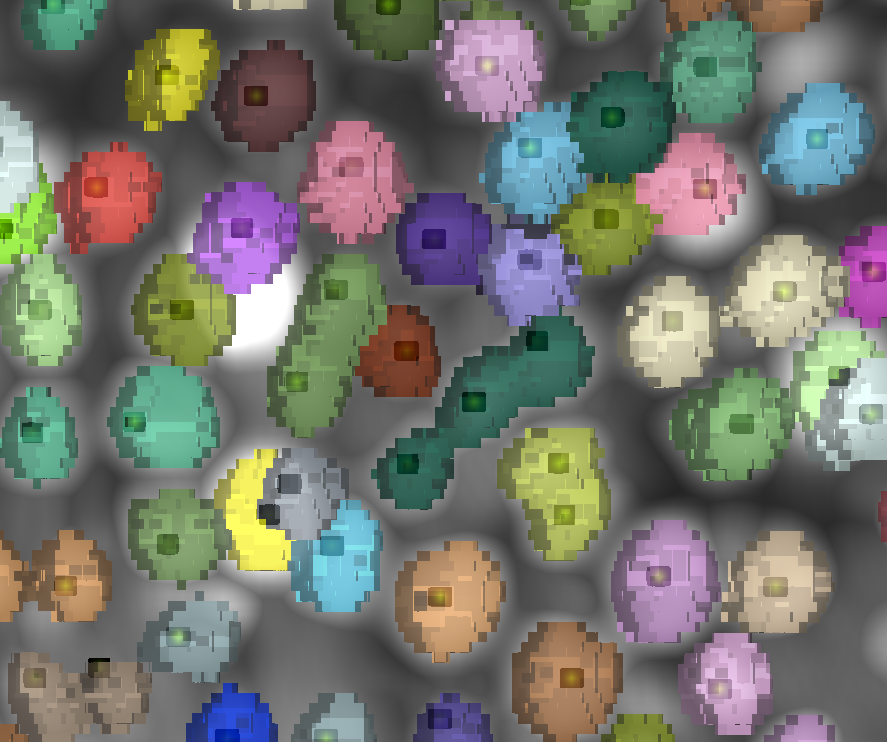

You have many annotations in the same region.

## Explore region 501

The dark green region has the label 501 in the watershed and engulfs the seeds 97, 501, 220

In [7]:
np.transpose(np.where(seeds_array==97)) in np.transpose(np.where(ws==501))

True

In [9]:
seeds_pos ={}

In [ ]:
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

In [11]:
seeds_pos[220]

array([205, 269,  61], dtype=uint16)

In [12]:
ws[tuple(seeds_pos[220].T)] = 220

In [13]:
ws[tuple(seeds_pos[97].T)] = 97

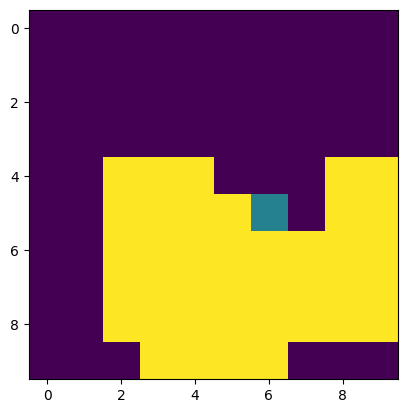

In [19]:
plt.imshow(ws[200:210, 269, 55:65])

In [168]:
viewer = napari.Viewer()
viewer.add_image(im_for_ws[200:230, 250:275, 55:65])
# viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_image(seeds_array[200:230, 250:275, 55:65])
viewer.add_labels(ws[200:230, 250:275, 55:65])
napari.run()

In reality, the seeds that look like they are inside the undersegmented regions, ARE NOT INCLUDED IN THE REGIONS (label = 97 is viewed in pink, outside of region 501)

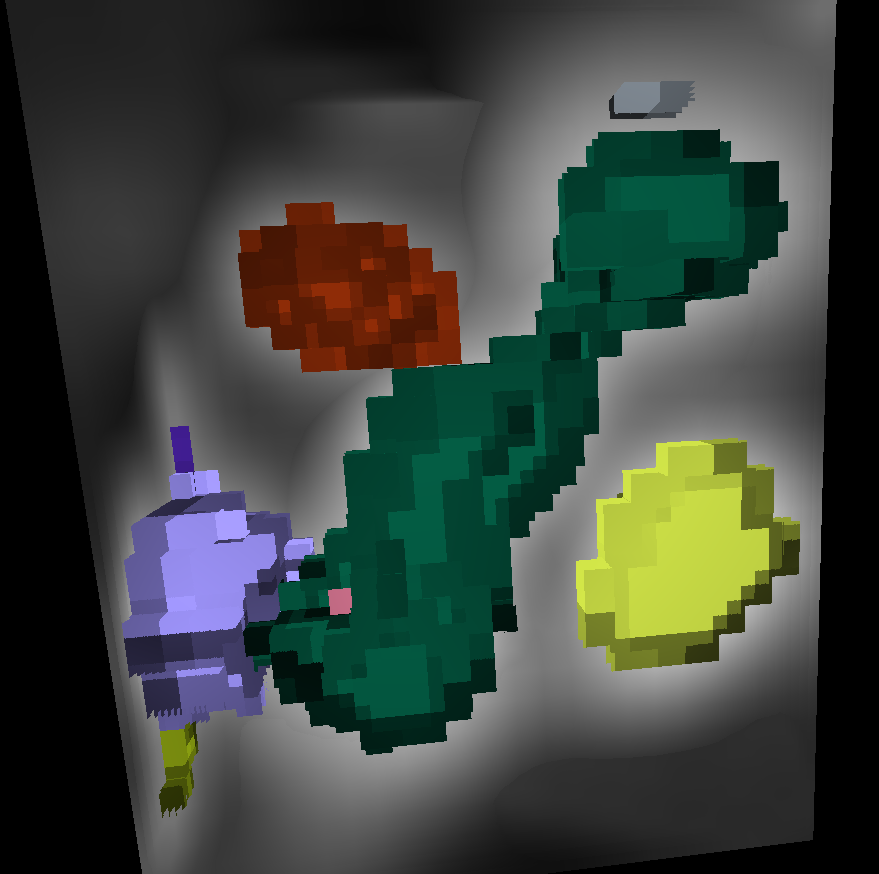

And 220 is here in yellow

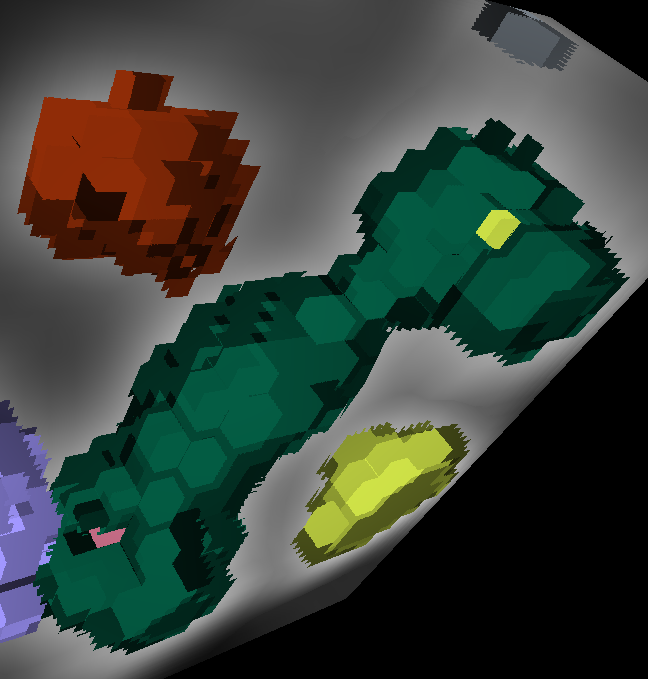

In [52]:
seeds_array.shape

(300, 472, 525)

In [67]:
seeds_array[tuple(seeds_pos[97].T)]

np.int16(97)

In [ ]:
ws[tuple(seeds_pos[97].T)]

Let's test for another annotation too, 292 ws encloses(?) both 546 and 292 seeds

In [18]:
ws[tuple(seeds_pos[546])]

np.int16(0)

In [196]:
pos_tst = seeds_pos[292]

In [200]:
rr = 10
viewer = napari.Viewer()
viewer.add_image(im_for_ws[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
# viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_image(seeds_array[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
viewer.add_labels(ws[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
napari.run()

Same thing turns to be the case for the 292 region: it just has a hole in the pixel position of the other annotation.

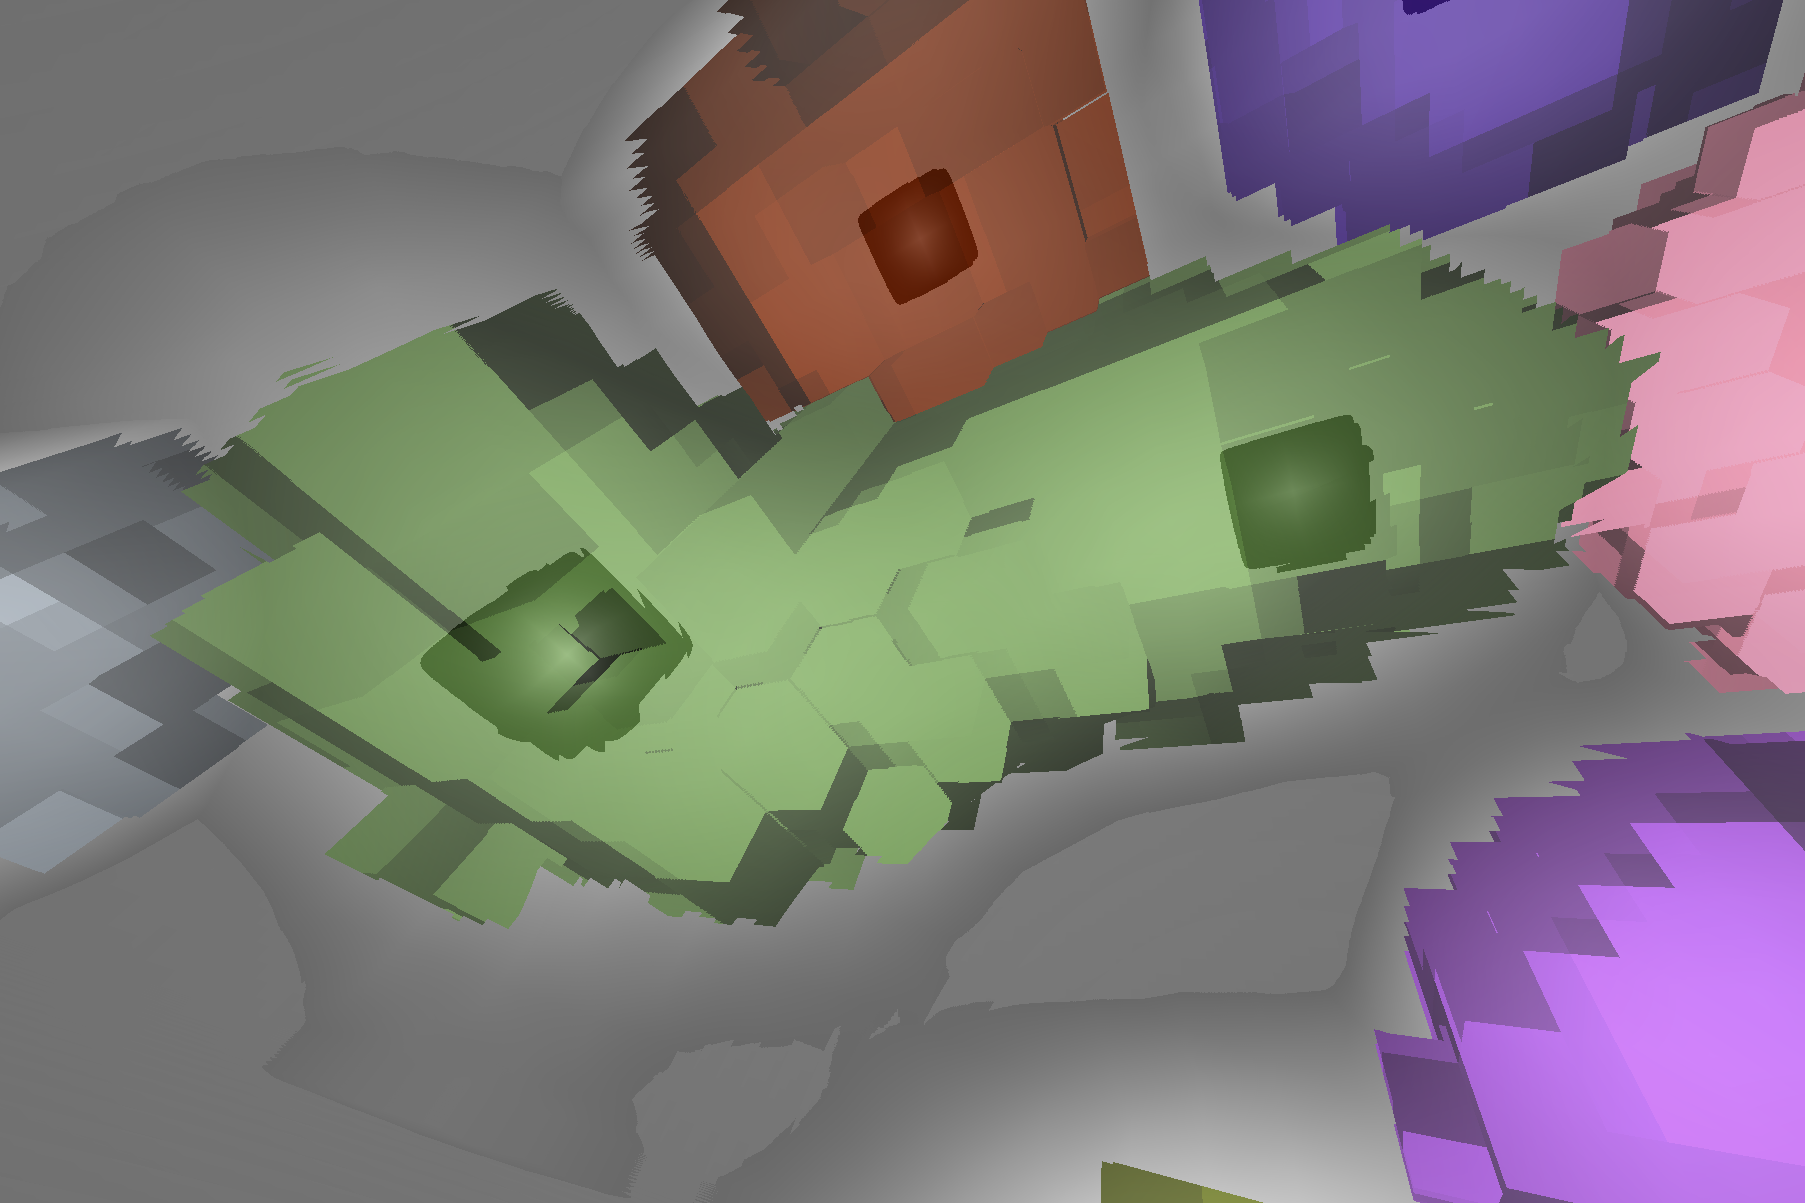

## Identifying multiples cases

In [10]:
pp = seeds_pos[546]
# print(ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2])
li = np.unique(ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2])
mask = li > 0
updated_li = li[mask]
print(updated_li)
print(len(li))

[292]
2


In [11]:
# FINDING WHAT TO DELETE
missed_multiples = set()
big_seeds = set()

for annotat in all_seeds:
    pp = seeds_pos[annotat]
    image_crop = ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2] # small image around annotation
    labels_in_crop = np.unique(image_crop)
    if ws[tuple(pp)] == 0 and len(labels_in_crop)>1: # 0 is de facto included -> len>=1
        missed_multiples.add(annotat)
        for i in range(1,len(labels_in_crop)): # for the case that it is ajascent to more that one region
            big_seeds.add(labels_in_crop[i])

In [13]:
import copy

new_ws = copy.deepcopy(ws)

# CLEAR THE WATERSHED FROM GIVEN LABELS
for label in big_seeds:
    new_ws[ws==label] = 0

In [26]:
from skimage.morphology import ball

def add_lost_seeds(ws_in:np.ndarray,
                    seeds_pos,
                    missed_seeds,
                    min_vol=300
):
    """Adds a shperical mask around all missing seeds.
    """

    rad = (3*min_vol/(4*np.pi))**(1/3) # the sphere will have the minimum allowed volume
    rad = int(np.round(rad).astype(np.uint8))
    ball(rad)
    sph_mask = ball(rad) > 0 # make a boolean mask with shperical shape

    for label in missed_seeds:
        pos_ms = seeds_pos[label]
        print(pos_ms)
        padd = ws_in < 0 # this is False everywhere
        padd[pos_ms[0]-rad:pos_ms[0] + rad +1, pos_ms[1]-rad:pos_ms[1]+rad+1, pos_ms[2]-rad:pos_ms[2]+rad+1] = sph_mask
        ws_in[padd] = label

In [27]:
seeds_pos[1]

array([148, 395, 263], dtype=uint16)

In [14]:
new_ws = main.add_lost_seeds(new_ws, seeds_pos, missed_multiples.union(big_seeds))

In [16]:
len(missed_multiples.union(big_seeds))

67

In [29]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
# viewer.add_image(seeds_array)
viewer.add_labels(new_ws)
viewer.add_labels(ws)

napari.run()

## Identifying weirdly shaped regions

In [69]:
from skimage.measure import regionprops

labels = []
areas = []
sol = []
ext = []
fer_diam = []

for reg in regionprops(new_ws, raw_image):
    labels.append(reg.label)
    areas.append(reg.area)
    sol.append(reg.solidity)
    ext.append(reg.extent) # pixels area / bbox area
    fer_diam.append(reg.feret_diameter_max)

fer_diam = np.asarray(fer_diam)
areas = np.asarray(areas)

max_vol = 4/3 * 3.1415 * fer_diam**3
closeness_to_shpere = areas/max_vol

In [73]:
ws.shape

(300, 472, 525)

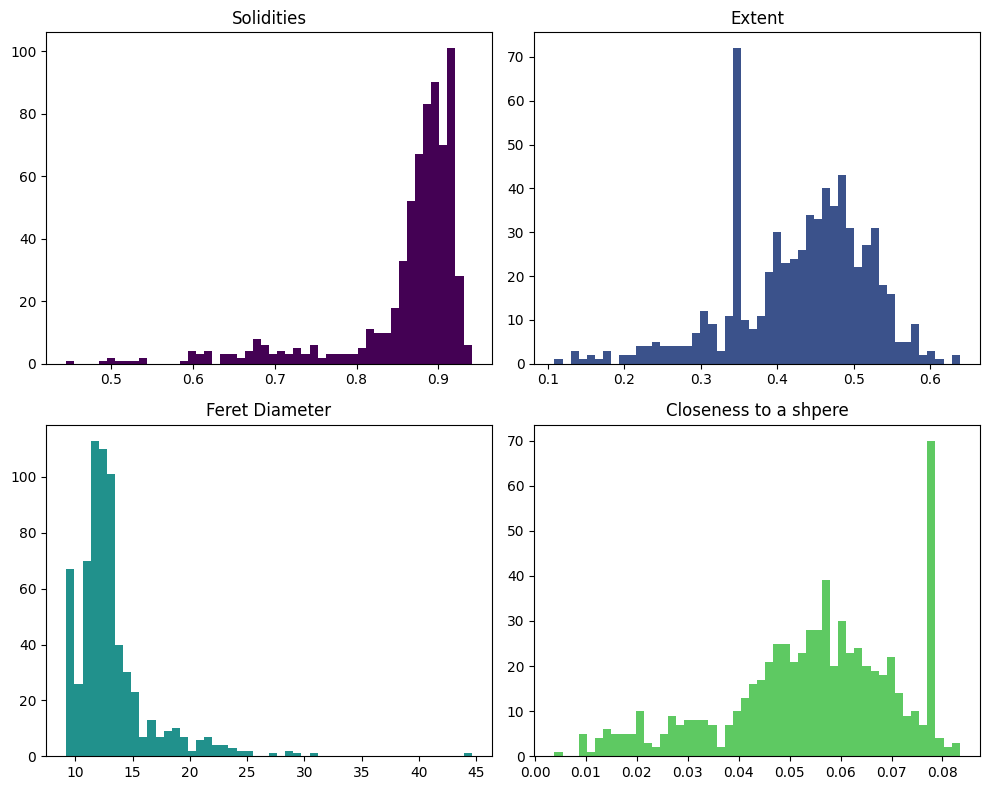

In [71]:
import matplotlib.pyplot as plt

colors = plt.cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(sol, bins=50, color=colors[0])
axes[0,0].set_title('Solidities')

axes[0,1].hist(ext, bins=50, color=colors[1])
axes[0,1].set_title('Extent')

axes[1,0].hist(fer_diam, bins=50, color=colors[2])
axes[1,0].set_title('Feret Diameter')

axes[1,1].hist(closeness_to_shpere, bins=50, color=colors[3])
axes[1,1].set_title('Closeness to a shpere')

plt.tight_layout()  # Prevents overlapping labels
plt.show()

In [39]:
labels  = np.asarray(labels, dtype=int)
sol = np.asarray(sol)

In [56]:
mask = sol < 0.65

In [57]:
weird_regs_ws = np.zeros_like(ws)

for lab in labels[mask]:
    weird_regs_ws[new_ws == lab] = 999

In [72]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
# viewer.add_image(seeds_array)
viewer.add_labels(weird_regs_ws)
viewer.add_labels(new_ws)

napari.run()

Good at identifying the abominations

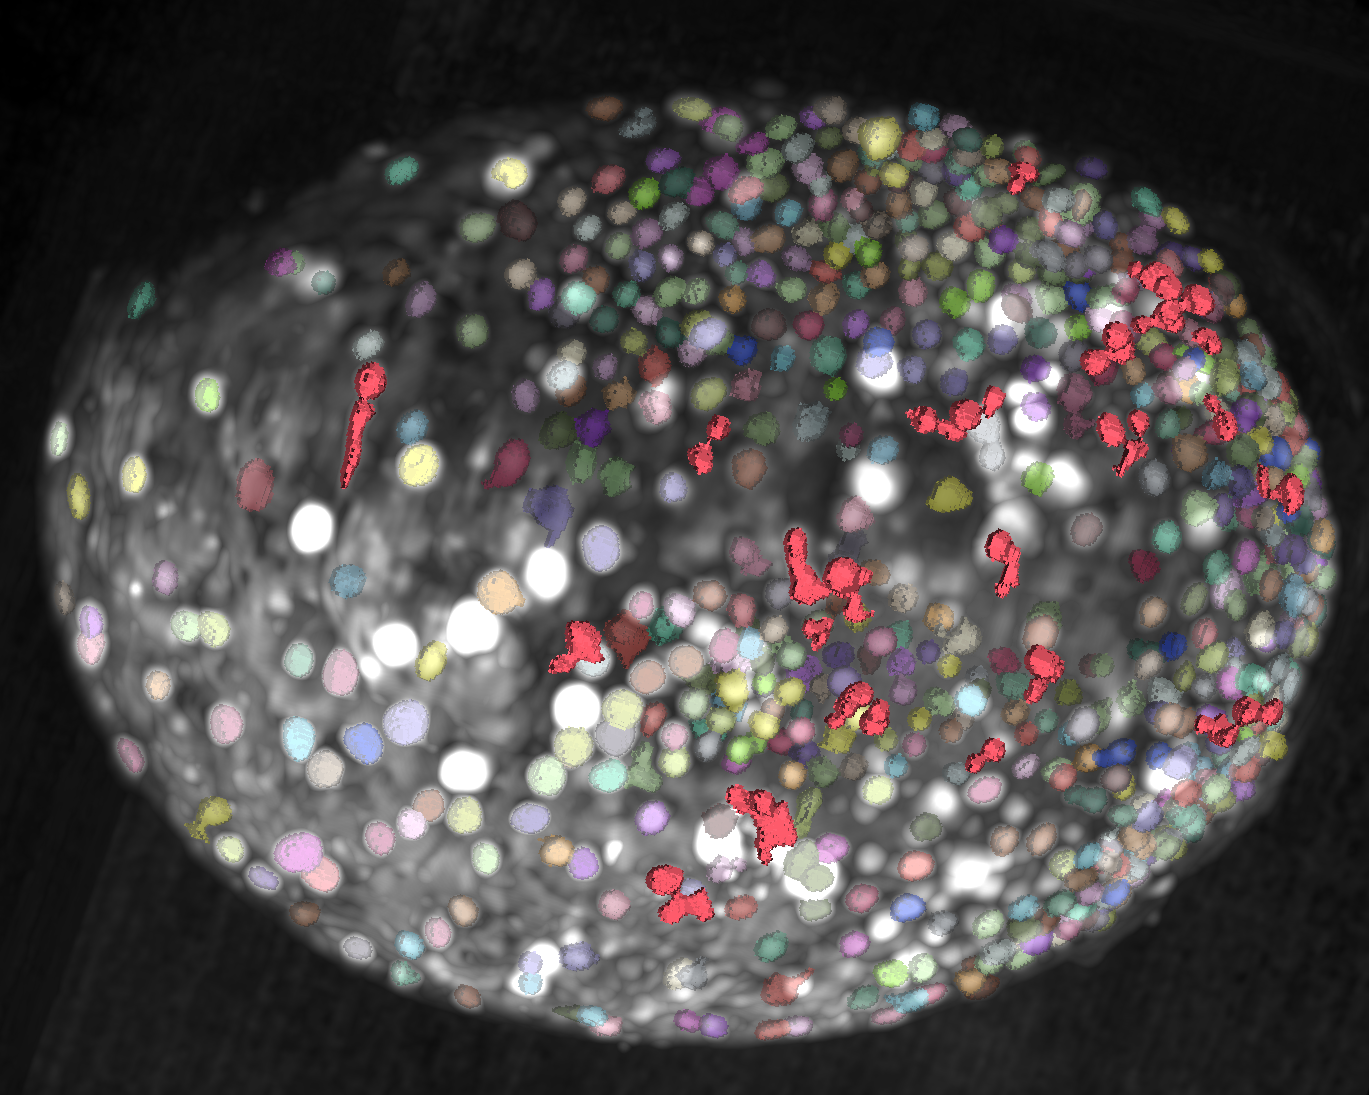